(b) 5×5 Derivative of Gaussian Kernels (σ = 2)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sigma = 2
size = 5
center = size // 2

Gx = np.zeros((size, size))
Gy = np.zeros((size, size))

for i in range(size):
    for j in range(size):
        x = i - center
        y = j - center
        
        G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
        
        Gx[i, j] = - (x / sigma**2) * G
        Gy[i, j] = - (y / sigma**2) * G

print("5x5 Derivative of Gaussian Kernel (Gx, σ=2):")
print(np.round(Gx, 4))
print("\n5x5 Derivative of Gaussian Kernel (Gy, σ=2):")
print(np.round(Gy, 4))

5x5 Derivative of Gaussian Kernel (Gx, σ=2):
[[ 0.0073  0.0106  0.0121  0.0106  0.0073]
 [ 0.0053  0.0077  0.0088  0.0077  0.0053]
 [-0.     -0.     -0.     -0.     -0.    ]
 [-0.0053 -0.0077 -0.0088 -0.0077 -0.0053]
 [-0.0073 -0.0106 -0.0121 -0.0106 -0.0073]]

5x5 Derivative of Gaussian Kernel (Gy, σ=2):
[[ 0.0073  0.0053 -0.     -0.0053 -0.0073]
 [ 0.0106  0.0077 -0.     -0.0077 -0.0106]
 [ 0.0121  0.0088 -0.     -0.0088 -0.0121]
 [ 0.0106  0.0077 -0.     -0.0077 -0.0106]
 [ 0.0073  0.0053 -0.     -0.0053 -0.0073]]


(c) Visualize 51×51 Derivative of Gaussian as 3D Surface Plot

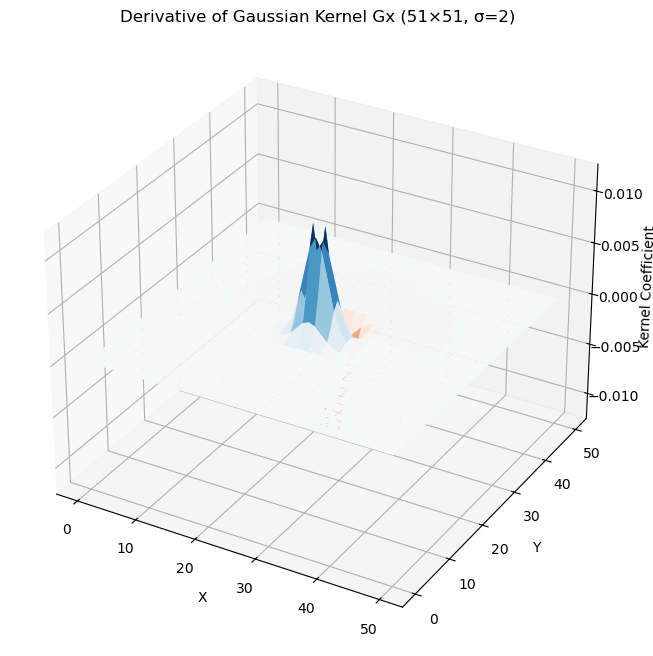

In [2]:
size_large = 51
center_large = size_large // 2
sigma_large = 2
Gx_large = np.zeros((size_large, size_large))

for i in range(size_large):
    for j in range(size_large):
        x = i - center_large
        y = j - center_large
        G = (1 / (2 * np.pi * sigma_large**2)) * np.exp(-(x**2 + y**2) / (2 * sigma_large**2))
        Gx_large[i, j] = - (x / sigma_large**2) * G

X = np.arange(size_large)
Y = np.arange(size_large)
X, Y = np.meshgrid(X, Y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Gx_large, cmap='RdBu')
ax.set_title(f'Derivative of Gaussian Kernel Gx (51×51, σ={sigma_large})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Kernel Coefficient')
plt.show()

(d) Apply Derivative of Gaussian Kernels to Grayscale Image

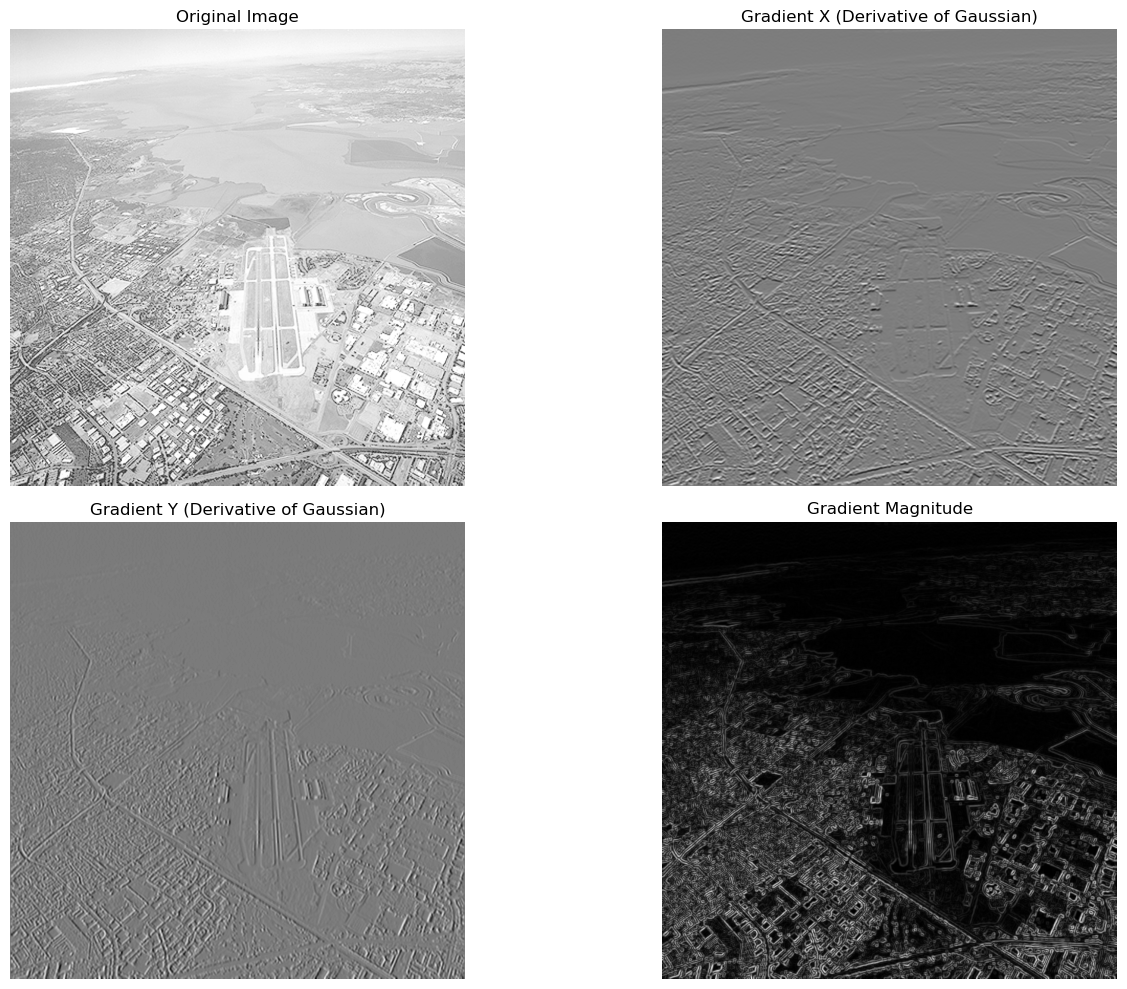

In [3]:
img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)

img_Gx = cv2.filter2D(img, cv2.CV_64F, Gx)
img_Gy = cv2.filter2D(img, cv2.CV_64F, Gy)
gradient_magnitude = np.sqrt(img_Gx**2 + img_Gy**2)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_Gx, cmap='gray')
plt.title('Gradient X (Derivative of Gaussian)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_Gy, cmap='gray')
plt.title('Gradient Y (Derivative of Gaussian)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

(e) Comparisson with OpenCV's Sobel Operator

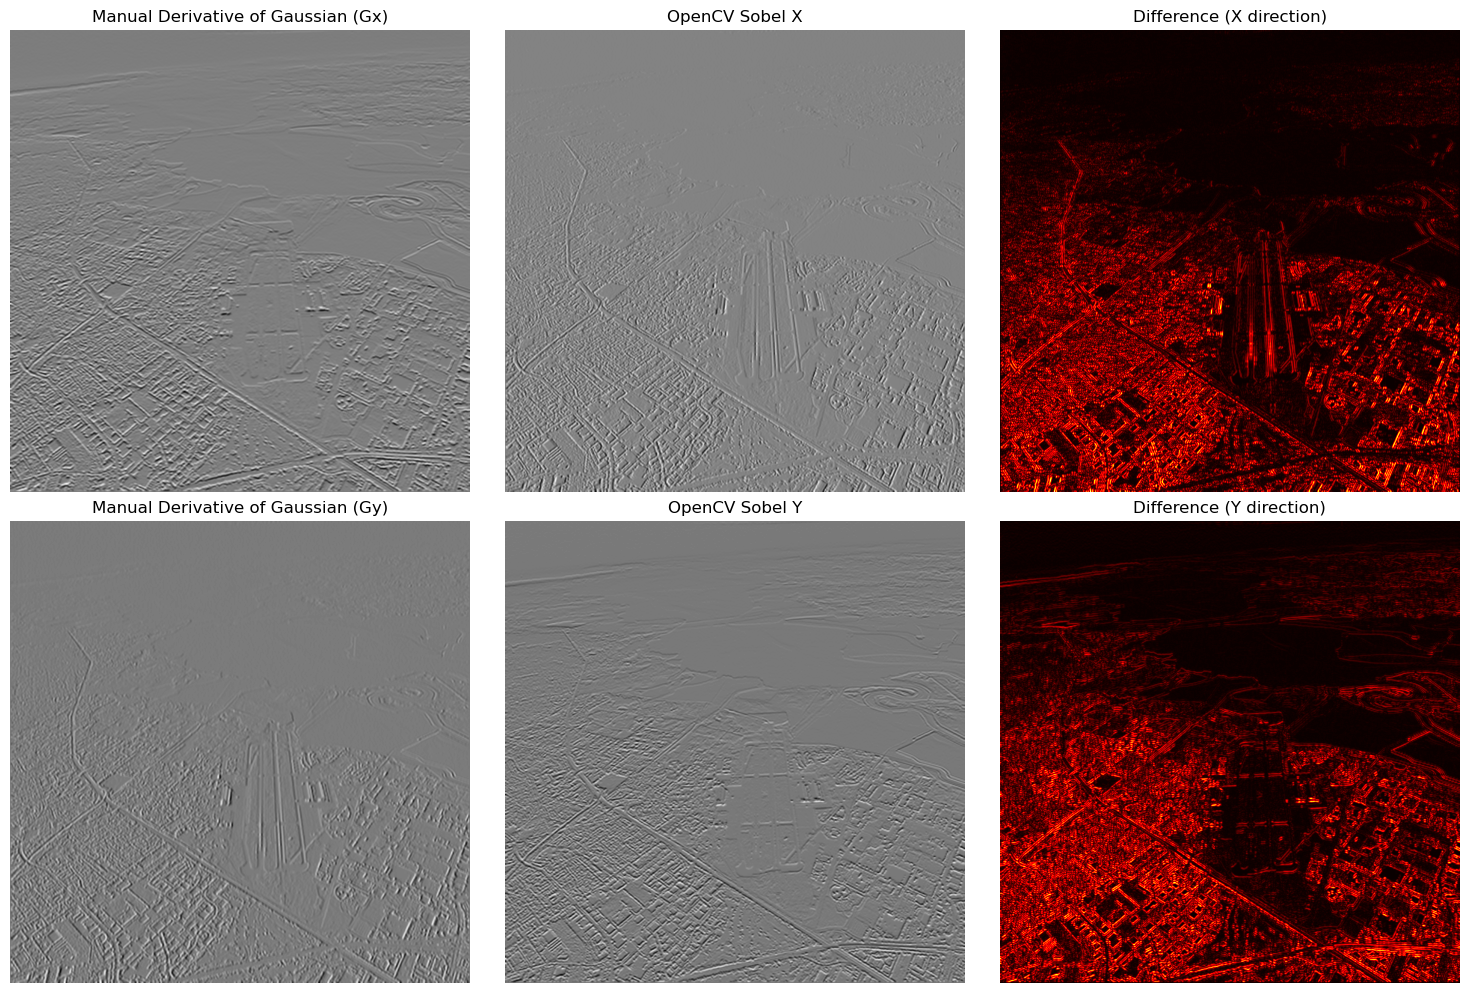

Comparison between Manual Derivative of Gaussian and Sobel:
Mean difference in X gradient: 733.8938
Mean difference in Y gradient: 860.7969


In [4]:
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_Gx, cmap='gray')
plt.title('Manual Derivative of Gaussian (Gx)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(sobel_x, cmap='gray')
plt.title('OpenCV Sobel X')
plt.axis('off')

plt.subplot(2, 3, 3)
diff_x = np.abs(img_Gx - sobel_x)
plt.imshow(diff_x, cmap='hot')
plt.title('Difference (X direction)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_Gy, cmap='gray')
plt.title('Manual Derivative of Gaussian (Gy)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(sobel_y, cmap='gray')
plt.title('OpenCV Sobel Y')
plt.axis('off')

plt.subplot(2, 3, 6)
diff_y = np.abs(img_Gy - sobel_y)
plt.imshow(diff_y, cmap='hot')
plt.title('Difference (Y direction)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Comparison between Manual Derivative of Gaussian and Sobel:")
print(f"Mean difference in X gradient: {np.mean(diff_x):.4f}")
print(f"Mean difference in Y gradient: {np.mean(diff_y):.4f}")